In [2]:
import sys
import numpy as np
import pandas as pd
import scipy.sparse as sp

import scanpy as sc
import anndata as ad
import scvi

import torch
import torch.nn as nn
import torch.nn.functional as F

import mygene
import matplotlib.pyplot as plt

from perturbnet.util import *
from perturbnet.cinn.flow import *
from perturbnet.genotypevae.genotypeVAE import *
from perturbnet.data_vae.vae import *
from perturbnet.cinn.flow_generate import SCVIZ_CheckNet2Net

import os
import time



In [3]:



# ============================================================
# 1. Load AnnData (RAW COUNTS)
# ============================================================

adata = ad.read_h5ad("data/TfCf_All_rawcounts.h5ad")

print("Loaded AnnData:", adata)
print("X dtype:", adata.X.dtype)
print("X max:", adata.X.max())


# ============================================================
# 2. Load and align metadata
# ============================================================

import pandas as pd

# Load metadata
meta_ex = pd.read_csv("data/ex.vivo_metadata.tsv", sep="\t")
meta_in = pd.read_csv("data/in.vivo_metadata.tsv", sep="\t")

print(meta_ex.head())
print(meta_ex.columns)

# Concatenate ex vivo and in vivo metadata
meta = pd.concat([meta_ex, meta_in], axis=0, ignore_index=True)

assert meta["rn"].is_unique

# Extract core 10x barcode
adata.obs["barcode"] = adata.obs_names.str[-18:]  # last 18 chars
meta["barcode"] = meta["rn"].str[:18]            # first 18 chars

# Check how many are common
common = adata.obs["barcode"].isin(meta["barcode"])
print(f"Common cells: {common.sum()} / {adata.n_obs}")

# Keep only metadata rows that exist in adata
meta_sub = meta[meta["barcode"].isin(adata.obs["barcode"])].copy()

# Remove duplicates in metadata
meta_sub = meta_sub.drop_duplicates(subset="barcode")

# Set barcode as index for alignment
meta_sub = meta_sub.set_index("barcode")

# Subset adata.obs to only overlapping barcodes
adata = adata[adata.obs["barcode"].isin(meta_sub.index)].copy()

# Reorder metadata to match adata
meta_sub = meta_sub.loc[adata.obs["barcode"]]

print("AnnData shape:", adata.shape)
print("Metadata shape:", meta_sub.shape)

# Confirm all barcodes aligned
all_match = (adata.obs["barcode"] == meta_sub.index).all()
print("All barcodes aligned:", all_match)

# ============================================================
# 3. Attach metadata to AnnData
# ============================================================
# ============================================================
# 3. Attach metadata to AnnData
# ============================================================

adata.obs["guide"] = meta_sub["guide"].values
adata.obs["cell_type"] = meta_sub["functional.cluster"].values
adata.obs["tissue"] = meta_sub["tissue"].values
adata.obs["timepoint"] = meta_sub["timepoint"].values
adata.obs["mixscape_class"] = meta_sub["mixscape_class.global"].values

adata.obs["genotype"] = (
    adata.obs["guide"].str.split("_").str[0].astype("category")
)
# 4. GO onehot matrix
#============================================================
adata.obs["genotype"] = adata.obs["genotype"].astype("category")

perturb_genes = sorted(
    g for g in adata.obs['genotype'].cat.categories
    if g not in ['NTC', 'NA']  # remove controls or missing
)

# recreate YOUR split
train_mask = (
    ((adata.obs["tissue"] == "ex.vivo") & (adata.obs["genotype"] != "NA")) |
    ((adata.obs["tissue"] == "ex.vivo") & (adata.obs["genotype"] == "NTC")) |
    ((adata.obs["tissue"] == "in.vivo") & (adata.obs["genotype"] == "NTC"))
)

test_mask = (
    (adata.obs["tissue"] == "in.vivo") &
    (adata.obs["genotype"] != "NTC") &
    (adata.obs["genotype"] != "NA")
)

adata_train = adata[train_mask].copy()
adata_test  = adata[test_mask].copy()

print("Train:", adata_train.shape, "Test:", adata_test.shape)
#set up training
scvi.data.setup_anndata(adata_train)   # uses adata_train.X
#
import scipy.sparse as sp
import scvi

# ensure CSR for speed
if sp.issparse(adata_train.X) and not sp.isspmatrix_csr(adata_train.X):
    adata_train.X = adata_train.X.tocsr()

# create the layer the model expects
adata_train.layers["counts"] = adata_train.X.copy()

# IMPORTANT: register using the same layer as training
scvi.data.setup_anndata(adata_train, layer="counts")

scvi_model = scvi.model.SCVI.load("./result/", adata=adata_train, use_cuda=False)
print("Loaded scVI. n_latent:", scvi_model.model.n_latent)

#
import scipy.sparse as sp
import scvi

# ensure same genes
adata_test = adata_test[:, adata_train.var_names].copy()

# ensure counts layer exists
if "counts" not in adata_test.layers:
    adata_test.layers["counts"] = adata_test.X.copy()

if sp.issparse(adata_test.layers["counts"]) and not sp.isspmatrix_csr(adata_test.layers["counts"]):
    adata_test.layers["counts"] = adata_test.layers["counts"].tocsr()

scvi.data.setup_anndata(adata_test, layer="counts")

adata_train.obsm["X_scvi"] = scvi_model.get_latent_representation(adata_train)
adata_test.obsm["X_scvi"]  = scvi_model.get_latent_representation(adata_test)

print(adata_train.obsm["X_scvi"].shape, adata_test.obsm["X_scvi"].shape)
#


Loaded AnnData: AnnData object with n_obs × n_vars = 451185 × 22364
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'toAnalyse', 'tissue', 'markers', 'timepoint', 'md5sum', 'md5sumFile', 's', 'sample_old', 'sample_new', 'sample_broad', 'sample_found', 'md5sumFound', 'percent.mt'
    var: 'name'
X dtype: float32
X max: 15695.0
                                       rn     orig.ident    nCount_RNA  \
0  AAACCCAAGAAATCCA-1_Mye_OP2-OP3_NM_4d_1  SeuratProject  58319.712960   
1      AAACCCAAGACCTCCG-1_LSK_OP1_NM_9d_1  SeuratProject   7903.502747   
2      AAACCCAAGAGCATAT-1_LSK_OP4_NM_9d_1  SeuratProject  55264.975843   
3      AAACCCAAGATACCAA-1_LSK_OP3_NM_7d_1  SeuratProject   5200.125104   
4      AAACCCAAGATGAACT-1_LSK_OP2_NM_7d_1  SeuratProject  12710.565145   

   nFeature_RNA  nCount_SCT  nFeature_SCT  SCT_snn_res.0.8  seurat_clusters  \
0          7051       26334          5442                6                6   
1          2628        9683          2631                0      

In [4]:
#genotypevae human to mouse setup mouse2z is the final 
import numpy as np
from sklearn.neighbors import NearestNeighbors
A = adata_train

X = A.obsm["X_scvi"]
t = A.obs["tissue"].astype(str).values

k = 30
nn = NearestNeighbors(n_neighbors=k + 1).fit(X)
idx = nn.kneighbors(X, return_distance=False)[:, 1:]

same_frac = np.mean(t[idx] == t[:, None], axis=1)
mix_score = 1.0 - same_frac

print("Mean tissue mixing score:", float(mix_score.mean()))
print("Median tissue mixing score:", float(np.median(mix_score)))
#
import torch
from perturbnet.genotypevae.genotypeVAE import GenotypeVAE

device = "cuda" if torch.cuda.is_available() else "cpu"
geno_dir = "./genotypeVAE"  # where gene.npy, sparse_gene_anno_matrix.npz, model_params.pt live

vae = GenotypeVAE().to(device)
vae.load_state_dict(torch.load(f"{geno_dir}/model_params.pt", map_location=device))
vae.eval()
#mapping mouse to human
import numpy as np
import pandas as pd
from scipy import sparse
import os

import torch
from perturbnet.genotypevae.genotypeVAE import GenotypeVAE

device = "cuda" if torch.cuda.is_available() else "cpu"
geno_dir = "./genotypeVAE"  # where gene.npy, sparse_gene_anno_matrix.npz, model_params.pt live

vae = GenotypeVAE().to(device)
vae.load_state_dict(torch.load(f"{geno_dir}/model_params.pt", map_location=device))
vae.eval()
import numpy as np
import pandas as pd
from scipy import sparse
import os

# MGI ortholog map
hom = pd.read_csv("HOM_MouseHumanSequence.rpt", sep="\t", header=None, dtype=str)
hom = hom[hom[0] != "DB Class Key"].copy()
hom3 = hom[[0, 2, 3]].copy()
hom3.columns = ["hom_id", "taxid", "symbol"]

mouse = hom3[hom3["taxid"] == "10090"][["hom_id","symbol"]].rename(columns={"symbol":"mouse_symbol"})
human = hom3[hom3["taxid"] == "9606"][["hom_id","symbol"]].rename(columns={"symbol":"human_symbol"})
pairs = mouse.merge(human, on="hom_id", how="inner")

counts = pairs.groupby("hom_id").agg(
    n_mouse=("mouse_symbol","nunique"),
    n_human=("human_symbol","nunique")
).reset_index()
one2one_ids = set(counts.query("n_mouse==1 and n_human==1")["hom_id"])
pairs_1to1 = pairs[pairs["hom_id"].isin(one2one_ids)].drop_duplicates()
mouse2human = dict(zip(pairs_1to1["mouse_symbol"], pairs_1to1["human_symbol"]))

# pretrained GO library
gene_data = np.load(os.path.join(geno_dir, "gene.npy"), allow_pickle=True)
anno = sparse.load_npz(os.path.join(geno_dir, "sparse_gene_anno_matrix.npz"))
gene_to_lib = {g: i for i, g in enumerate(gene_data)}

mouse_genes = [g for g in adata.obs["genotype"].cat.categories if g not in ["NTC","NA"]]

mouse_kept, lib_idx = [], []
for mg in mouse_genes:
    hg = mouse2human.get(mg)
    if hg is None:
        continue
    hgU = hg.upper()
    if hgU not in gene_to_lib:
        continue
    mouse_kept.append(mg)
    lib_idx.append(gene_to_lib[hgU])

onehot = anno[lib_idx].toarray().astype(np.float32)  # (80,15988) in your case
print("onehot:", onehot.shape)
x = torch.tensor(onehot, dtype=torch.float32, device=device)
with torch.no_grad():
    out = vae(x)

z_pert = out[1] if isinstance(out, (tuple, list)) else out
print("z_pert:", z_pert.shape)  # (80,10)

mouse2z = {mouse_kept[i]: z_pert[i].detach().cpu().numpy().astype(np.float32)
           for i in range(len(mouse_kept))}

def filter_and_build_cond(adata_sub, mouse2z, control_label="NTC"):
    z_dim = next(iter(mouse2z.values())).shape[0]
    z0 = np.zeros((z_dim,), dtype=np.float32)

    keep = np.zeros(adata_sub.n_obs, dtype=bool)
    cond = np.zeros((adata_sub.n_obs, z_dim), dtype=np.float32)

    genos = adata_sub.obs["genotype"].astype(str).values
    for i, g in enumerate(genos):
        if g == control_label:
            keep[i] = True
            cond[i] = z0
        elif g in mouse2z:
            keep[i] = True
            cond[i] = mouse2z[g]
        else:
            keep[i] = False  # drops Gltscr1 automatically

    return adata_sub[keep].copy(), cond[keep]

adata_train_cinn, cond_train = filter_and_build_cond(adata_train, mouse2z, "NTC")
adata_test_cinn,  cond_test  = filter_and_build_cond(adata_test,  mouse2z, "NTC")

print("CINN train:", adata_train_cinn.shape, cond_train.shape)
print("CINN test :", adata_test_cinn.shape,  cond_test.shape)

assert adata_train_cinn.obsm["X_scvi"].shape[0] == cond_train.shape[0]
#sanity checks
#sanity checks
print("train_cinn cells:", adata_train_cinn.n_obs, "cond:", cond_train.shape)
print("test_cinn  cells:", adata_test_cinn.n_obs,  "cond:", cond_test.shape)

print("X_scvi dim train:", adata_train_cinn.obsm["X_scvi"].shape)
print("X_scvi dim test :", adata_test_cinn.obsm["X_scvi"].shape)

# Make sure scVI latent dim matches what CINN expects as x-dimension
zdim = adata_train_cinn.obsm["X_scvi"].shape[1]
print("scVI latent dim:", zdim)

# Condition dim (from GenotypeVAE)
cdim = cond_train.shape[1]
print("cond dim:", cdim)
#sanity check
print("Train tissue counts:\n", adata_train_cinn.obs["tissue"].value_counts())
print("Train genotype counts (top 10):\n", adata_train_cinn.obs["genotype"].value_counts().head(10))

# specifically: how many in vivo non-NTC in training?
invivo_nonntc = ((adata_train_cinn.obs["tissue"]=="in.vivo") & (adata_train_cinn.obs["genotype"]!="NTC")).sum()
print("in vivo non-NTC in training:", invivo_nonntc)


Mean tissue mixing score: 0.057121161116076784
Median tissue mixing score: 0.0
onehot: (80, 15988)
z_pert: torch.Size([80, 10])
CINN train: (105259, 22364) (105259, 10)
CINN test : (101972, 22364) (101972, 10)
train_cinn cells: 105259 cond: (105259, 10)
test_cinn  cells: 101972 cond: (101972, 10)
X_scvi dim train: (105259, 10)
X_scvi dim test : (101972, 10)
scVI latent dim: 10
cond dim: 10
Train tissue counts:
 ex.vivo    89781
in.vivo    15478
Name: tissue, dtype: int64
Train genotype counts (top 10):
 NTC        30322
Carm1       6482
Ehmt2       4593
Rbbp4       3601
Mbd3        3575
Prmt1       3543
Smarcd1     2838
Prmt5       2595
Smc2        2542
Men1        2512
Name: genotype, dtype: int64
in vivo non-NTC in training: 0


In [5]:
#cinn
from perturbnet.util import prepare_embeddings_cinn

import numpy as np

# 1) ordered_all_trt: integer code per genotype
adata_train.obs["ordered_all_trt"] = adata_train.obs["genotype"].astype("category").cat.codes.astype(int)

# 2) ordered_all_onehot: per-cell condition embedding (z_dim)
z_dim = next(iter(mouse2z.values())).shape[0]
z0 = np.zeros((z_dim,), dtype=np.float32)

cond_all = np.zeros((adata_train.n_obs, z_dim), dtype=np.float32)
for i, g in enumerate(adata_train.obs["genotype"].astype(str).values):
    if g == "NTC":
        cond_all[i] = z0
    else:
        cond_all[i] = mouse2z.get(g, z0)  # if missing, falls back to zeros (or you can drop later)

adata_train.obsm["ordered_all_onehot"] = cond_all
print("ordered_all_onehot:", adata_train.obsm["ordered_all_onehot"].shape)
# only those which maps
#Build the treatment list (strings)
import numpy as np

# clean genotype as plain strings
adata_train.obs["genotype"] = adata_train.obs["genotype"].astype(str)

# keep only perturbations we can embed
known = set(mouse2z.keys()) | {"NTC"}
adata_train = adata_train[adata_train.obs["genotype"].isin(known)].copy()

# treatments present in this AnnData (unique)
trt_list = np.unique(adata_train.obs["genotype"].values)
print("n treatments:", len(trt_list), "first:", trt_list[:10])
adata.layers["counts"] = adata.X.copy()
adata.obs["perturb_string"] = adata.obs["genotype"].astype(str)
import numpy as np

ordered_all_onehot: (172294, 10)
n treatments: 42 first: ['Ash1l' 'Atf7ip' 'Bcl11a' 'Brd9' 'Carm1' 'Cbx3' 'Cebpa' 'Chaf1a' 'Chd4'
 'Chmp2a']


In [42]:
ct_df = pd.get_dummies(adata_train_cinn.obs["cell_type"].astype(str), prefix="ct")
celltypes = ct_df.columns.tolist()
import numpy as np, pandas as pd

A = adata_train_cinn  # this is per-cell training data for CINN
x_train = A.obsm["X_scvi"].astype(np.float32)      # (N,10)
z_gene  = cond_train.astype(np.float32)            # (N,10)

tissue_df = pd.get_dummies(A.obs["tissue"].astype(str), prefix="tissue")
ct_df = pd.get_dummies(A.obs["cell_type"].astype(str), prefix="ct")
sample_df = pd.get_dummies(A.obs["sample_new"].astype(str), prefix="sample")
guide_df     = pd.get_dummies(A.obs["guide"].astype(str), prefix="guide")  # your functional.cluster stored as cell_type

c_train = np.concatenate(
    [z_gene,
     tissue_df.to_numpy(np.float32),
     ct_df.to_numpy(np.float32),
     sample_df.to_numpy(np.float32),
     guide_df.to_numpy(np.float32)],
    axis=1
).astype(np.float32)

print("x_train:", x_train.shape)
print("c_train:", c_train.shape, " (= 10 + 2 + n_celltypes)")
np.save("cinn_tissue_columns.npy", tissue_df.columns.to_numpy())
np.save("cinn_ct_columns.npy", ct_df.columns.to_numpy())
np.save("cinn_sample_columns.npy", sample_df.columns.to_numpy())
np.save("cinn_guide_columns.npy", guide_df.columns.to_numpy())
print("Saved tissue columns:", tissue_df.columns.tolist())
print("Saved ct columns (n):", len(ct_df.columns))


x_train: (105259, 10)
c_train: (105259, 162)  (= 10 + 2 + n_celltypes)
Saved tissue columns: ['tissue_ex.vivo', 'tissue_in.vivo']
Saved ct columns (n): 21


In [ ]:
#########################The model training#############################
import torch
from torch.utils.data import DataLoader, TensorDataset
from perturbnet.cinn.flow import ConditionalFlatCouplingFlow
import numpy as np, os, time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# --- 0) Full candidate set for training ---
train_mask = ((A.obs["tissue"] == "ex.vivo") & (A.obs["genotype"].isin(["NTC", "KO"]))) | \
             ((A.obs["tissue"] == "in.vivo") & (A.obs["genotype"] == "NTC"))
x_train_all = x_train[train_mask]
c_train_all = c_train[train_mask]

# --- 1) Task-specific small fraction for validation ---
val_frac = 0.05  # 5% for validation

# ex vivo NTC -> ex vivo KO
mask_ex_ko = (A.obs["tissue"] == "ex.vivo") & (A.obs["genotype"].isin(["NTC", "KO"]))
idx_ex_ko = np.where(mask_ex_ko)[0]
n_val_ex_ko = max(1, int(len(idx_ex_ko) * val_frac))
val_idx_ex_ko = np.random.choice(idx_ex_ko, n_val_ex_ko, replace=False)

# ex vivo NTC -> in vivo NTC
mask_ex_in = ((A.obs["tissue"] == "ex.vivo") & (A.obs["genotype"] == "NTC")) | \
             ((A.obs["tissue"] == "in.vivo") & (A.obs["genotype"] == "NTC"))
idx_ex_in = np.where(mask_ex_in)[0]
n_val_ex_in = max(1, int(len(idx_ex_in) * val_frac))
val_idx_ex_in = np.random.choice(idx_ex_in, n_val_ex_in, replace=False)

# --- 2) Build training set (exclude validation indices) ---
all_val_idx = np.unique(np.concatenate([val_idx_ex_ko, val_idx_ex_in]))
train_idx = np.setdiff1d(np.where(train_mask)[0], all_val_idx)

x_train_final = x_train[train_idx]
c_train_final = c_train[train_idx]

x_val_ex_ko_final = x_train[val_idx_ex_ko]
c_val_ex_ko_final = c_train[val_idx_ex_ko]

x_val_ex_in_final = x_train[val_idx_ex_in]
c_val_ex_in_final = c_train[val_idx_ex_in]

print("Training samples:", x_train_final.shape[0])
print("Val ex KO samples:", x_val_ex_ko_final.shape[0])
print("Val ex/in samples:", x_val_ex_in_final.shape[0])

# --- 3) Build DataLoader ---
train_dataset = TensorDataset(torch.tensor(x_train_final, dtype=torch.float32),
                              torch.tensor(c_train_final, dtype=torch.float32))
train_dl = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True)

# --- CINN flow, optimizer, NLL, training loop --- (same as before)


# --- 3) Build CINN flow ---
flow = ConditionalFlatCouplingFlow(
    in_channels=10,
    embedding_dim=10,
    conditioning_dim=c_train_final.shape[1],  # use actual training set
    conditioning_depth=2,
    n_flows=20,
    hidden_dim=1024,
    hidden_depth=2,
).to(device)

# --- 4) Optimizer ---
opt = torch.optim.Adam(flow.parameters(), lr=5e-5)

# --- 5) NLL function ---
def nll(xb, cb):
    xb = xb.to(device)
    cb = cb.to(device)
    xb4 = xb.unsqueeze(-1).unsqueeze(-1)
    z, log_det = flow(xb4, cb)[:2]
    z = z.squeeze(-1).squeeze(-1)
    log_pz = -0.5 * (z**2 + np.log(2 * np.pi)).sum(dim=1)
    return -(log_pz + log_det).mean()



# --- 6) Training loop ---
n_epochs = 45
train_loss_list = []
val_loss_ex_ko_list = []
val_loss_ex_in_list = []

save_dir = "data_generated/my_run6/"
os.makedirs(save_dir, exist_ok=True)

start_time = time.time()

for ep in range(1, n_epochs + 1):
    flow.train()
    train_losses = []

    for xb, cb in train_dl:
        opt.zero_grad()
        loss = nll(xb, cb)
        loss.backward()
        opt.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))

    # --- Task-specific validation (fraction only) ---
    flow.eval()
    with torch.no_grad():
        # ex vivo KO validation
        val_losses_ex_ko = [
            nll(
                torch.tensor(x_val_ex_ko_final[i:i + 256], dtype=torch.float32),
                torch.tensor(c_val_ex_ko_final[i:i + 256], dtype=torch.float32),
            ).item()
            for i in range(0, len(x_val_ex_ko_final), 256)
        ]
        val_loss_ex_ko = float(np.mean(val_losses_ex_ko))

        # ex vivo NTC -> in vivo NTC validation
        val_losses_ex_in = [
            nll(
                torch.tensor(x_val_ex_in_final[i:i + 256], dtype=torch.float32),
                torch.tensor(c_val_ex_in_final[i:i + 256], dtype=torch.float32),
            ).item()
            for i in range(0, len(x_val_ex_in_final), 256)
        ]
        val_loss_ex_in = float(np.mean(val_losses_ex_in))

    # --- Record ---
    train_loss_list.append(train_loss)
    val_loss_ex_ko_list.append(val_loss_ex_ko)
    val_loss_ex_in_list.append(val_loss_ex_in)

    print(
        f"Epoch {ep:02d} | Train NLL: {train_loss:.4f} | "
        f"Val ex KO: {val_loss_ex_ko:.4f} | Val ex/in: {val_loss_ex_in:.4f}"
    )

    # --- Save checkpoint every 5 epochs ---
    if ep % 5 == 0:
        ckpt_path = os.path.join(save_dir, f"cinn_model_epoch_{ep:02d}.pt")
        torch.save(
            {
                "epoch": ep,
                "model_state_dict": flow.state_dict(),
                "optimizer_state_dict": opt.state_dict(),
                "train_loss": train_loss,
                "val_loss_ex_ko": val_loss_ex_ko,
                "val_loss_ex_in": val_loss_ex_in,
            },
            ckpt_path,
        )
        print(f"Checkpoint saved: {ckpt_path}")

# --- 7) Save final model and results ---
torch.save(flow.state_dict(), os.path.join(save_dir, "cinn_model.pt"))

np.save(
    os.path.join(save_dir, "train_loss.npy"),
    np.array(train_loss_list, dtype=np.float32),
)
np.save(
    os.path.join(save_dir, "val_loss_ex_ko.npy"),
    np.array(val_loss_ex_ko_list, dtype=np.float32),
)
np.save(
    os.path.join(save_dir, "val_loss_ex_in.npy"),
    np.array(val_loss_ex_in_list, dtype=np.float32),
)
np.save(
    os.path.join(save_dir, "training_time.npy"),
    np.array(time.time() - start_time, dtype=np.float32),
)

print("Training complete. Model and losses saved to:", save_dir)


Training samples: 28098
Val ex KO samples: 742
Val ex/in samples: 1516
Epoch 01 | Train NLL: -4.8130 | Val ex KO: -7.4617 | Val ex/in: -8.1585
Epoch 02 | Train NLL: -8.5919 | Val ex KO: -8.4479 | Val ex/in: -9.4011
Epoch 03 | Train NLL: -9.4017 | Val ex KO: -8.6921 | Val ex/in: -9.9178
Epoch 04 | Train NLL: -10.4490 | Val ex KO: -8.8765 | Val ex/in: -10.4108
Epoch 05 | Train NLL: -10.8319 | Val ex KO: -9.2886 | Val ex/in: -10.9644
Checkpoint saved: ./my_run6/cinn_training_full/cinn_model_epoch_05.pt
Epoch 06 | Train NLL: -11.1757 | Val ex KO: -9.3353 | Val ex/in: -11.0377
Epoch 07 | Train NLL: -11.3955 | Val ex KO: -9.4162 | Val ex/in: -11.2290
Epoch 08 | Train NLL: -11.5303 | Val ex KO: -9.8262 | Val ex/in: -11.5909
Epoch 09 | Train NLL: -11.6237 | Val ex KO: -9.8344 | Val ex/in: -11.6355
Epoch 10 | Train NLL: -11.7947 | Val ex KO: -9.6982 | Val ex/in: -11.5675
Checkpoint saved: ./my_run6/cinn_training_full/cinn_model_epoch_10.pt
Epoch 11 | Train NLL: -11.9072 | Val ex KO: -9.8381 | V

In [10]:
import numpy as np
import os

save_dir = "data_generated/my_run6/cinn_training_full"
os.makedirs(save_dir, exist_ok=True)

train_loss = np.array([
    -4.8567, -8.5198, -9.3940, -10.6142, -11.7064,
    -12.1593, -12.5789, -12.8041, -13.0651, -13.1785,
    -13.3737, -13.5463, -13.6418, -13.7894, -13.8277,
    -13.9798, -14.0011, -14.0933, -14.1863, -14.2792,
    -14.2984, -14.3419, -14.3775, -14.4906, -14.5410,
    -14.5836, -14.6606, -14.6963, -14.6871, -14.7697,
    -14.8324, -14.8091, -14.9388, -14.9224, -14.9606,
    -14.9972, -15.0656, -15.0685, -15.1403, -15.1484,
    -15.2045, -15.2382, -15.2321, -15.2600, -15.3440
], dtype=np.float32)

val_ex_ko = np.array([
    -7.3272, -8.8719, -8.3302, -10.8541, -11.2462,
    -11.2896, -11.8619, -11.8339, -12.0896, -11.3799,
    -12.0201, -12.4707, -12.4651, -12.1509, -12.5993,
    -12.4055, -12.6439, -12.5883, -12.7806, -12.6591,
    -12.8403, -12.6125, -12.6947, -12.8252, -12.9004,
    -12.7975, -12.8203, -12.7887, -12.8698, -12.9389,
    -12.8252, -12.9598, -12.7512, -12.8944, -12.9385,
    -12.7393, -12.8005, -12.9259, -12.8311, -12.8255,
    -12.9416, -12.7798, -12.7134, -12.7986, -12.8450
], dtype=np.float32)

val_ex_in = np.array([
    -7.4442, -9.2019, -8.5435, -11.2114, -11.7824,
    -12.0261, -12.3943, -12.7502, -13.0084, -12.4401,
    -13.0644, -13.2911, -13.3706, -13.1773, -13.4910,
    -13.2514, -13.5965, -13.4980, -13.7075, -13.5594,
    -13.8166, -13.4185, -13.7318, -13.8432, -13.8209,
    -13.7980, -13.8612, -13.7736, -13.9519, -13.9555,
    -13.8339, -13.9849, -13.8864, -13.9400, -13.9357,
    -13.8455, -13.9684, -13.8042, -13.7932, -13.7894,
    -13.8508, -13.6907, -13.5989, -13.6197, -13.7670
], dtype=np.float32)

np.save(os.path.join(save_dir, "train_loss.npy"), train_loss)
np.save(os.path.join(save_dir, "val_loss_ex_ko.npy"), val_ex_ko)
np.save(os.path.join(save_dir, "val_loss_ex_in.npy"), val_ex_in)

print("✅ Loss values successfully reconstructed and saved")

✅ Loss values successfully reconstructed and saved


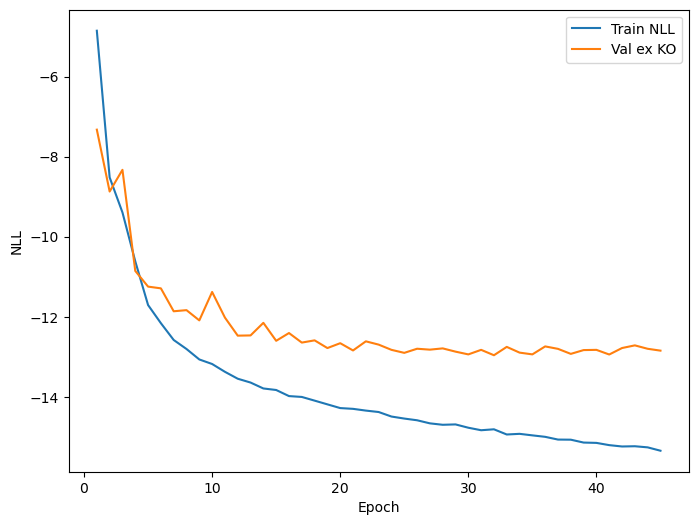

In [17]:
path_cinn_model_save = "data_generated/my_run6/cinn_training_full/"
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "data_generated/my_run6/cinn_training_full/"

train = np.load(path + "train_loss.npy")
val = np.load(path + "val_loss_ex_ko.npy")

df = pd.DataFrame({
    "Epoch": range(1, len(train)+1),
    "Train NLL": train,
    "Val ex KO": val
}).set_index("Epoch")

df.plot(figsize=(8,6))
plt.ylabel("NLL")
plt.show()

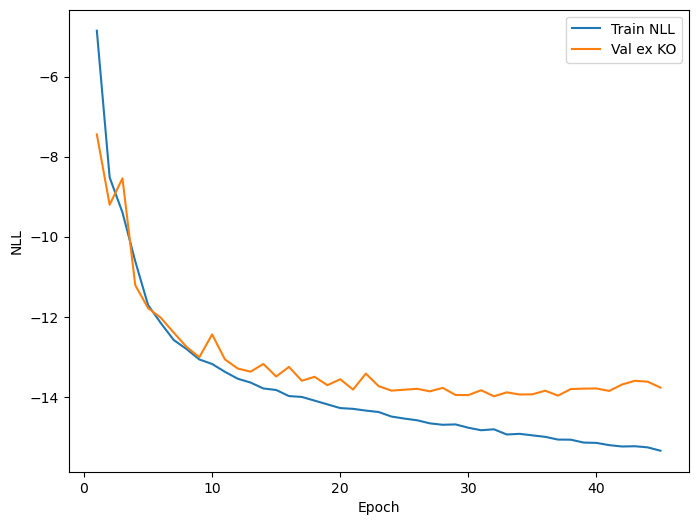

In [18]:
path_cinn_model_save = "data_generated/my_run6/cinn_training_full/"
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "data_generated/my_run6/cinn_training_full/"

train = np.load(path + "train_loss.npy")
val = np.load(path + "val_loss_ex_in.npy")

df = pd.DataFrame({
    "Epoch": range(1, len(train)+1),
    "Train NLL": train,
    "Val ex KO": val
}).set_index("Epoch")

df.plot(figsize=(8,6))
plt.ylabel("NLL")
plt.show()

In [22]:
#########################The model training#############################
import torch
from torch.utils.data import DataLoader, TensorDataset
from perturbnet.cinn.flow import ConditionalFlatCouplingFlow
import numpy as np, os, time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# --- 0) Full candidate set for training ---
train_mask = ((A.obs["tissue"] == "ex.vivo") & (A.obs["genotype"].isin(["NTC", "KO"]))) | \
             ((A.obs["tissue"] == "in.vivo") & (A.obs["genotype"] == "NTC"))
x_train_all = x_train[train_mask]
c_train_all = c_train[train_mask]

# --- 1) Task-specific small fraction for validation ---
val_frac = 0.05  # 5% for validation

# ex vivo NTC -> ex vivo KO
mask_ex_ko = (A.obs["tissue"] == "ex.vivo") & (A.obs["genotype"].isin(["NTC", "KO"]))
idx_ex_ko = np.where(mask_ex_ko)[0]
n_val_ex_ko = max(1, int(len(idx_ex_ko) * val_frac))
val_idx_ex_ko = np.random.choice(idx_ex_ko, n_val_ex_ko, replace=False)

# ex vivo NTC -> in vivo NTC
mask_ex_in = ((A.obs["tissue"] == "ex.vivo") & (A.obs["genotype"] == "NTC")) | \
             ((A.obs["tissue"] == "in.vivo") & (A.obs["genotype"] == "NTC"))
idx_ex_in = np.where(mask_ex_in)[0]
n_val_ex_in = max(1, int(len(idx_ex_in) * val_frac))
val_idx_ex_in = np.random.choice(idx_ex_in, n_val_ex_in, replace=False)

# --- 2) Build training set (exclude validation indices) ---
all_val_idx = np.unique(np.concatenate([val_idx_ex_ko, val_idx_ex_in]))
train_idx = np.setdiff1d(np.where(train_mask)[0], all_val_idx)

x_train_final = x_train[train_idx]
c_train_final = c_train[train_idx]

x_val_ex_ko_final = x_train[val_idx_ex_ko]
c_val_ex_ko_final = c_train[val_idx_ex_ko]

x_val_ex_in_final = x_train[val_idx_ex_in]
c_val_ex_in_final = c_train[val_idx_ex_in]

print("Training samples:", x_train_final.shape[0])
print("Val ex KO samples:", x_val_ex_ko_final.shape[0])
print("Val ex/in samples:", x_val_ex_in_final.shape[0])

Training samples: 28098
Val ex KO samples: 742
Val ex/in samples: 1516


In [36]:

device = "cuda" if torch.cuda.is_available() else "cpu"

flow = ConditionalFlatCouplingFlow(
    in_channels=10,
    embedding_dim=10,
    conditioning_dim=c_train_final.shape[1],  # use actual training set
    conditioning_depth=2,
    n_flows=20,
    hidden_dim=1024,
    hidden_depth=2,
).to(device)

ckpt = torch.load(
    "data_generated/my_run6/cinn_training_full/cinn_model_epoch_35.pt",
    map_location=device
)

flow.load_state_dict(ckpt["model_state_dict"])
flow.eval()



ConditionalFlatCouplingFlow(
  (embedder): BasicFullyConnectedNet(
    (main): Sequential(
      (0): Linear(in_features=162, out_features=256, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=256, out_features=256, bias=True)
      (5): LeakyReLU(negative_slope=0.01)
      (6): Linear(in_features=256, out_features=10, bias=True)
    )
  )
  (sub_layers): ModuleList(
    (0): ConditionalFlatDoubleCouplingFlowBlock(
      (norm_layer): ActNorm()
      (coupling): ConditionalDoubleVectorCouplingBlock(
        (s): ModuleList(
          (0): BasicFullyConnectedNet(
            (main): Sequential(
              (0): Linear(in_features=15, out_features=1024, bias=True)
              (1): LeakyReLU(negative_slope=0.01)
              (2): Linear(in_features=1024, out_features=1024, bias=True)
              (3): LeakyReLU(negative_slope=0.01)
             

In [43]:
#Prepare test scVI latents
adata_test.obsm["X_scvi"] = scvi_model.get_latent_representation(adata_test)
x_test = adata_test.obsm["X_scvi"].astype(np.float32)


In [44]:
#Build test conditioning vector
z_dim = next(iter(mouse2z.values())).shape[0]
z0 = np.zeros((z_dim,), dtype=np.float32)

z_gene_test = np.zeros((adata_test.n_obs, z_dim), dtype=np.float32)
for i, g in enumerate(adata_test.obs["genotype"].astype(str).values):
    z_gene_test[i] = mouse2z.get(g, z0)


In [50]:
import numpy as np

tissue_cols = np.load("cinn_tissue_columns.npy", allow_pickle=True)
ct_cols     = np.load("cinn_ct_columns.npy", allow_pickle=True)

sample_cols = np.load("cinn_sample_columns.npy", allow_pickle=True)
guide_cols     = np.load("cinn_guide_columns.npy", allow_pickle=True)

#tissue onehot
tissue_df_test = pd.get_dummies(
    adata_test.obs["tissue"].astype(str),
    prefix="tissue"
).reindex(columns=tissue_cols, fill_value=0)
#cell type onehot
ct_df_test = pd.get_dummies(
    adata_test.obs["cell_type"].astype(str),
    prefix="ct"
).reindex(columns=ct_cols, fill_value=0)
#sample
sample_df_test = pd.get_dummies(
    adata_test.obs["sample_new"].astype(str),
    prefix="sample"
).reindex(columns=sample_cols, fill_value=0)
#guide
guide_df_test = pd.get_dummies(
    adata_test.obs["guide"].astype(str),
    prefix="guide"
).reindex(columns=guide_cols, fill_value=0)

In [48]:
assert list(tissue_df_test.columns) == list(np.load("cinn_tissue_columns.npy", allow_pickle=True))
assert list(ct_df_test.columns) == list(np.load("cinn_ct_columns.npy", allow_pickle=True))
assert list(sample_df_test.columns) == list(np.load("cinn_sample_columns.npy", allow_pickle=True))
assert list(guide_df_test.columns) == list(np.load("cinn_guide_columns.npy", allow_pickle=True))


In [51]:
c_test = np.concatenate(
    [
        z_gene_test,
        tissue_df_test.to_numpy(np.float32),
        ct_df_test.to_numpy(np.float32),
        sample_df_test.to_numpy(np.float32),
     guide_df_test.to_numpy(np.float32)],
    axis=1,
).astype(np.float32)

print("x_test:", x_test.shape)
print("c_test:", c_test.shape)


x_test: (155080, 10)
c_test: (155080, 162)


In [52]:
#evaluate test nll
@torch.no_grad()
def compute_nll(flow, x, c, batch_size=256):
    flow.eval()
    losses = []

    for i in range(0, x.shape[0], batch_size):
        xb = torch.tensor(x[i:i+batch_size], device=device)
        cb = torch.tensor(c[i:i+batch_size], device=device)

        xb4 = xb.unsqueeze(-1).unsqueeze(-1)
        z, log_det = flow(xb4, cb)[:2]
        z = z.squeeze(-1).squeeze(-1)

        log_pz = -0.5 * (z**2 + np.log(2*np.pi)).sum(dim=1)
        loss = -(log_pz + log_det).mean()
        losses.append(loss.item())

    return float(np.mean(losses))


In [53]:
#run test nll
test_nll = compute_nll(flow, x_test, c_test)
print("Test NLL:", test_nll)


Test NLL: -8.70312212442014


In [54]:
# Average per cell
avg_test_nll = test_nll / x_test.shape[0]
print("Average per cell:", avg_test_nll)


Average per cell: -5.61202097267226e-05


In [ ]:
import torch
import numpy as np
flow.eval()
batch_size = 256
x_test_pred_list = []

for i in range(0, c_test.shape[0], batch_size):
    cb = torch.tensor(c_test[i:i+batch_size], dtype=torch.float32, device=device)
    # sample z ~ N(0,1)
    z = torch.randn((cb.shape[0], x_train.shape[1]), dtype=torch.float32, device=device)
    z4 = z.unsqueeze(-1).unsqueeze(-1)

    # forward pass (your version of CINN)
    x_gen, _ = flow.forward(z4, cb)[:2]
    x_gen = x_gen.squeeze(-1).squeeze(-1)
    x_test_pred_list.append(x_gen.detach().cpu().numpy())  # <-- detach here

x_test_pred = np.concatenate(x_test_pred_list, axis=0)
print("Predicted scVI latent shape:", x_test_pred.shape)
np.save("data_generated/my_run6/x_test_pred_epoch35.npy", x_test_pred)


In [ ]:
x_test_pred = np.load("data_generated/my_run6/x_test_pred_epoch_35.npy")
print(x_test_pred.shape)


In [ ]:
import anndata as ad
import numpy as np

# Dimensions
n_cells = x_test_pred.shape[0]
n_genes = adata_train.n_vars  # must match scVI training genes

# 1️⃣ Create AnnData FIRST
adata_pred = ad.AnnData(
    X=np.zeros((n_cells, n_genes), dtype=np.float32)
)

# 2️⃣ Add required counts layer (THIS is what scVI wants)
adata_pred.layers["counts"] = np.zeros(
    (n_cells, n_genes), dtype=np.float32
)

# 3️⃣ Inject CINN → scVI latent
adata_pred.obsm["X_scvi"] = x_test_pred

# 4️⃣ Copy metadata
adata_pred.obs["cell_type"] = adata_test.obs["cell_type"].values
adata_pred.obs["tissue"] = adata_test.obs["tissue"].values
adata_pred.obs["genotype"] = adata_test.obs["genotype"].values

print(adata_pred)



In [17]:
import scanpy as sc
import scvi
scvi_model = scvi.model.SCVI.load(
    "result",
    adata=adata_train
)
pred_expr = scvi_model.get_normalized_expression(
    adata_pred,
    library_size=1e4
)

pred_expr_np = pred_expr.values
print("Predicted gene expression shape:", pred_expr_np.shape)
# should be (n_cells, n_genes)


INFO     Using data from adata.layers["counts"]                                                                    
INFO     Computing library size prior per batch                                                                    
INFO     Registered keys:['X', 'batch_indices', 'local_l_mean', 'local_l_var', 'labels']                           
INFO     Successfully registered anndata object containing 105259 cells, 22364 vars, 1 batches, 1 labels, and 0    
         proteins. Also registered 0 extra categorical covariates and 0 extra continuous covariates.               
INFO     Input adata not setup with scvi. attempting to transfer anndata setup                                     
INFO     .obs[_scvi_batch] not found in target, assuming every cell is same category                               
INFO     .obs[_scvi_labels] not found in target, assuming every cell is same category                              
INFO     Using data from adata.layers["counts"]                         

In [18]:
import numpy as np
import pandas as pd

# Assume:
# pred_expr_np: (n_cells, n_genes) numpy array
# adata_pred.obs has 'genotype', 'cell_type', 'tissue'
# adata_train.var_names has gene names

# Step 1: Create group keys
keys = list(zip(
    adata_pred.obs["genotype"].astype(str),
    adata_pred.obs["cell_type"].astype(str),
    adata_pred.obs["tissue"].astype(str)
))

# Step 2: Find unique groups
unique_keys, inverse_idx = np.unique(keys, return_inverse=True, axis=0)
n_groups = unique_keys.shape[0]
n_genes = pred_expr_np.shape[1]

# Step 3: Open CSV for writing
output_file = "predicted_expression_SUM_direct.csv"
with open(output_file, "w") as f:
    # Write header: first 3 columns are group keys, then gene names
    f.write("genotype,cell_type,tissue," + ",".join(adata_train.var_names) + "\n")

    # Step 4: Loop over each group and sum on the fly
    for g in range(n_groups):
        mask = inverse_idx == g
        group_sum = pred_expr_np[mask].sum(axis=0)  # shape: (n_genes,)
        line = ",".join([str(x) for x in unique_keys[g]] + [f"{x:.4f}" for x in group_sum])
        f.write(line + "\n")

print(f"✅ Aggregated expression written directly to {output_file}")


✅ Aggregated expression written directly to predicted_expression_SUM_direct.csv


In [ ]:
import pandas as pd
import numpy as np

# Convert predicted expression to DataFrame
pred_expr_df = pd.DataFrame(
    pred_expr_np,
    columns=adata_train.var_names,  # gene names
    index=adata_pred.obs.index      # cell barcodes
)

# Combine with metadata
metadata_df = adata_pred.obs[["genotype", "cell_type", "tissue"]].copy()
expr_with_meta = pd.concat([metadata_df, pred_expr_df], axis=1)

# Aggregate sum per genotype / cell_type / tissue
agg_expr = expr_with_meta.groupby(
    ["genotype", "cell_type", "tissue"], as_index=True
).sum()

# Save as CSV (much lighter than RDS)
agg_expr.to_csv("../vscratch/aarathy/predicted_expression_SUM.csv")
print("✅ Aggregated expression saved as CSV")


In [ ]:
# Copy predicted expression
expr_df = pred_expr.copy()

# Add grouping metadata
expr_df["genotype"] = adata_pred.obs["genotype"].values
expr_df["cell_type"] = adata_pred.obs["cell_type"].values
expr_df["tissue"] = adata_pred.obs["tissue"].values
sum_expr_ko_celltype_tissue = (
    expr_df
    .groupby(["genotype", "cell_type", "tissue"])
    .sum()
)
np.save("sum_expr.npy",sum_expr_ko_celltype_tissue)